In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/PatternRecog/heart_cleveland_upload.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [5]:
X = df.drop(columns = ['condition'])
y = df['condition']

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    int64  
 12  thal      297 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 30.3 KB


In [7]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 297 entries, 0 to 296
Series name: condition
Non-Null Count  Dtype
--------------  -----
297 non-null    int64
dtypes: int64(1)
memory usage: 2.4 KB


In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_cal, y_train, y_cal = train_test_split(
    X_temp, y_temp,
    test_size=0.20,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
models_and_grids = {

    "LogisticRegression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear"
            ))
        ]),
        {
            "clf__C": [0.01, 0.1, 1, 5, 10],
            "clf__penalty": ["l1", "l2"]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced"
            ))
        ]),
        {
            "clf__C": [0.1, 1, 5, 10],
            "clf__gamma": ["scale", 0.01, 0.05, 0.1]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        {
            "max_depth": [5, 8, 12],
            "min_samples_leaf": [2, 5, 10]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [150, 250],
            "learning_rate": [0.03, 0.05],
            "max_depth": [2, 3],
            "subsample": [0.8, 1.0]
        }
    )
}

In [11]:
best_models = {}

for name, (model, grid) in models_and_grids.items():

    gs = GridSearchCV(
        model,
        grid,
        scoring="roc_auc",
        cv=skf,
        n_jobs=-1,
        refit=True
    )

    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_

    print(f"{name} best CV AUROC: {gs.best_score_:.3f}")
    print(f"{name} best params: {gs.best_params_}\n")

LogisticRegression best CV AUROC: 0.895
LogisticRegression best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}

SVM best CV AUROC: 0.896
SVM best params: {'clf__C': 0.1, 'clf__gamma': 0.01}

RandomForest best CV AUROC: 0.884
RandomForest best params: {'max_depth': 5, 'min_samples_leaf': 10}

GradientBoosting best CV AUROC: 0.843
GradientBoosting best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}



In [14]:
from sklearn.frozen import FrozenEstimator

calibrated_models = {}

for name, model in best_models.items():

    model.fit(X_train, y_train)

    frozen_model = FrozenEstimator(model)

    cal_model = CalibratedClassifierCV(
        estimator=frozen_model,
        method="sigmoid",
        cv=5
    )

    cal_model.fit(X_cal, y_cal)
    calibrated_models[name] = cal_model

In [15]:
for name, model in calibrated_models.items():

    p = model.predict_proba(X_test)[:, 1]
    y_pred = (p >= 0.5).astype(int)

    print(f"\n{name}")
    print("AUROC:", roc_auc_score(y_test, p))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))


LogisticRegression
AUROC: 0.9308035714285714
Precision: 1.0
Recall: 0.8214285714285714
F1: 0.9019607843137255

SVM
AUROC: 0.9274553571428572
Precision: 1.0
Recall: 0.7857142857142857
F1: 0.88

RandomForest
AUROC: 0.9285714285714286
Precision: 0.875
Recall: 0.75
F1: 0.8076923076923077

GradientBoosting
AUROC: 0.9252232142857143
Precision: 0.9130434782608695
Recall: 0.75
F1: 0.8235294117647058


In [28]:
from sklearn.metrics import confusion_matrix

C_FN, C_FP = 5, 1

def selective_metrics(y_true, y_prob, tau):
    confident = (y_prob >= tau) | (y_prob <= 1 - tau)

    if confident.sum() == 0:
        return np.nan, np.nan, np.nan

    y_sel = y_true[confident]
    p_sel = y_prob[confident]
    y_pred = (p_sel >= 0.5).astype(int)

    # FORCE 2x2 confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_sel,
        y_pred,
        labels=[0, 1]
    ).ravel()

    coverage = confident.mean()
    risk = (C_FN * fn + C_FP * fp) / len(y_sel)
    fnr = fn / (fn + tp + 1e-9)

    return coverage, risk, fnr

In [29]:
OPERATING_TAUS = [0.6, 0.7, 0.8, 0.9]

print("OPERATING POINTS (τ-based)")

for tau in OPERATING_TAUS:
    print(f"\nConfidence threshold τ = {tau}")

    for name, model in calibrated_models.items():

        p_test = model.predict_proba(X_test)[:, 1]

        cov, risk, fnr = selective_metrics(
            y_test.values,
            p_test,
            tau
        )

        print(
            f"{name:20s} | "
            f"coverage={cov:.2f} | "
            f"risk={risk:.3f} | "
            f"FNR={fnr:.3f}"
        )

OPERATING POINTS (τ-based)

Confidence threshold τ = 0.6
LogisticRegression   | coverage=0.90 | risk=0.463 | FNR=0.200
SVM                  | coverage=0.88 | risk=0.472 | FNR=0.200
RandomForest         | coverage=0.92 | risk=0.582 | FNR=0.250
GradientBoosting     | coverage=0.92 | risk=0.564 | FNR=0.240

Confidence threshold τ = 0.7
LogisticRegression   | coverage=0.80 | risk=0.417 | FNR=0.174
SVM                  | coverage=0.78 | risk=0.426 | FNR=0.174
RandomForest         | coverage=0.68 | risk=0.244 | FNR=0.105
GradientBoosting     | coverage=0.73 | risk=0.227 | FNR=0.111

Confidence threshold τ = 0.8
LogisticRegression   | coverage=0.58 | risk=0.429 | FNR=0.167
SVM                  | coverage=0.53 | risk=0.156 | FNR=0.067
RandomForest         | coverage=0.47 | risk=0.179 | FNR=0.071
GradientBoosting     | coverage=0.50 | risk=0.167 | FNR=0.067

Confidence threshold τ = 0.9
LogisticRegression   | coverage=0.30 | risk=0.000 | FNR=0.000
SVM                  | coverage=0.28 | risk=0.0

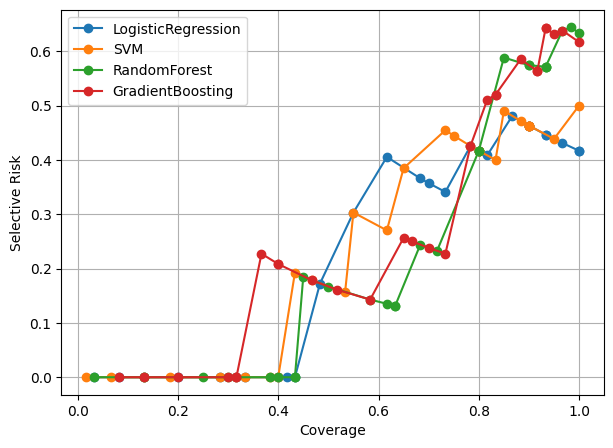

In [30]:
taus = np.linspace(0.5, 0.99, 30)

plt.figure(figsize=(7,5))
for name, model in calibrated_models.items():
    p = model.predict_proba(X_test)[:, 1]
    covs, risks = [], []
    for t in taus:
        c, r, _ = selective_metrics(y_test.values, p, t)
        covs.append(c)
        risks.append(r)
    plt.plot(covs, risks, marker="o", label=name)

plt.xlabel("Coverage")
plt.ylabel("Selective Risk")
plt.legend()
plt.grid()
plt.show()

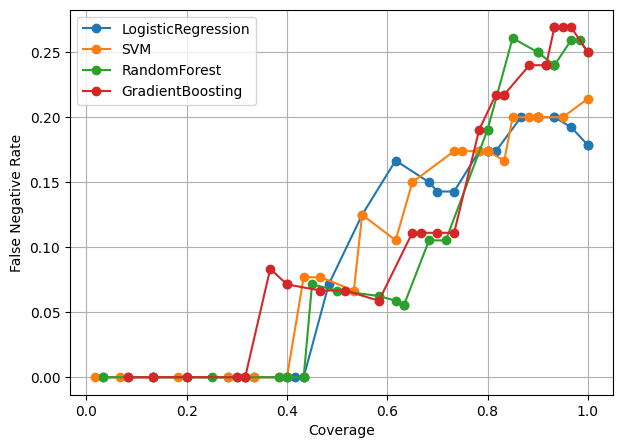

In [31]:
plt.figure(figsize=(7,5))
for name, model in calibrated_models.items():
    p = model.predict_proba(X_test)[:, 1]
    covs, fnrs = [], []
    for t in taus:
        c, _, f = selective_metrics(y_test.values, p, t)
        covs.append(c)
        fnrs.append(f)
    plt.plot(covs, fnrs, marker="o", label=name)

plt.xlabel("Coverage")
plt.ylabel("False Negative Rate")
plt.legend()
plt.grid()
plt.show()

In [23]:
final_model = calibrated_models["RandomForest"]
p_cal = final_model.predict_proba(X_cal)[:, 1]

q_low, q_m1, q_m2, q_high = np.quantile(p_cal, [0.25, 0.45, 0.55, 0.75])

def mu_low(p):
    if p <= q_low:
        return 1
    if p <= q_m1:
        return (q_m1 - p) / (q_m1 - q_low)
    return 0

def mu_med(p):
    if p <= q_low or p >= q_high:
        return 0
    if p <= q_m1:
        return (p - q_low) / (q_m1 - q_low)
    if p <= q_m2:
        return 1
    return (q_high - p) / (q_high - q_m2)

def mu_high(p):
    if p >= q_high:
        return 1
    if p >= q_m2:
        return (p - q_m2) / (q_high - q_m2)
    return 0

def fuzzy_decision(p):
    l, m, h = mu_low(p), mu_med(p), mu_high(p)
    if h > max(l, m):
        return 1
    if l > max(h, m):
        return 0
    return -1

In [32]:
p_test = final_model.predict_proba(X_test)[:, 1]
fuzzy_preds = np.array([fuzzy_decision(p) for p in p_test])

mask = fuzzy_preds != -1
coverage = mask.mean()

y_cov = y_test.values[mask]
d_cov = fuzzy_preds[mask]

fn = np.sum((d_cov == 0) & (y_cov == 1))
tp = np.sum((d_cov == 1) & (y_cov == 1))
fnr = fn / (fn + tp + 1e-9)

print("Coverage:", coverage)
print("FNR:", fnr)

Coverage: 0.6166666666666667
FNR: 0.05555555555246913


In [33]:
os.makedirs("saved_models", exist_ok=True)
joblib.dump(final_model, "saved_models/final_calibrated_rf.pkl")

['saved_models/final_calibrated_rf.pkl']